## Limpieza, Escalamiento y Transformación de Datos

Cuando estas en el EDA solamente se utiliza solamene el train set, en esta parte se analiza:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
PATH_CALIFORNIA = "/content/drive/MyDrive/machine_learning/california_housing/"
df_california_housing = pd.read_csv(f"{PATH_CALIFORNIA}housing.csv")

In [26]:
df_california_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [17]:
df_california_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


> Ojo si hay valores nulos los algoritmos no van a funcionar como se esperan

Hay 3 formas de solucionarlo:
- Eliminar las filas donde sean nulos. (No es recomendable ya que podemos eliminar datos importantes)
- Eliminar la caracteristicas completa. (No es recomendable ya que podemos eliminar datos importantes)
- Inyectar datos calculados en esos elementos (Recomendado) se le conoce como data imputation.

Conceptos:
- drop elimina la columna target
- .copy() evita SettingWithCopyWarning

In [21]:
TARGET = 'median_house_value'
X = df_california_housing.drop(TARGET, axis=1)
y = df_california_housing[TARGET].copy()

print(f'X shape : {X.shape}  → {X.columns.tolist()}')
print(f'y shape : {y.shape}  → {TARGET}')

X shape : (20640, 9)  → ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
y shape : (20640,)  → median_house_value


## ¿Qué es la inputación de datos?

Proceso en donde se reemplaza valores faltantes con estimaciones razonables. 

Cuando recolectas datos del mundo real, siempre hay huecos. Alguien no respondió una encuesta, un sensor falló, un campo era opcional. Esos huecos son NaN (Not a Number) en tu DataFrame.La alternativa obvia sería eliminar las filas con NaN, pero eso puede costarte el 20% de tus datos, y el modelo que entrenes con datos incompletos aprende distribuciones sesgadas.La imputación dice: "no eliminamos, estimamos".

Tipos de inputación:

- Simple: Se utiliza para reemplazar el valor faltante utilizando unicamente datos de esa columna.

Tiene 3 métodos:
1. Mean imputation: Reemplaza con la media de la columna. Para distribuciones simétricas, si la campana es simetrica la media y la mediana son casi iguales, utilizar la media.
2. Median Imputation: Si hay cola larga hacia la derecha (outliers, como salarios o precios de casas) no se va a ver tan afectada → la media se infla por esos extremos → usa mediana
3. Mode Imputation: Para variables categoricas reemplazar con el valor más frecuente.

- Multivariante o Basada en modelo: Usa otras columnas como predictores para estimar valores faltantes.
Se utiliza cuando las columnas están fuertemente correlacionadas con otras features.

- Imputación avanzada: va a crear modelos como regresión lineal para predecir los valores faltantes.

## Selección de imputación

### Por tipos de variables

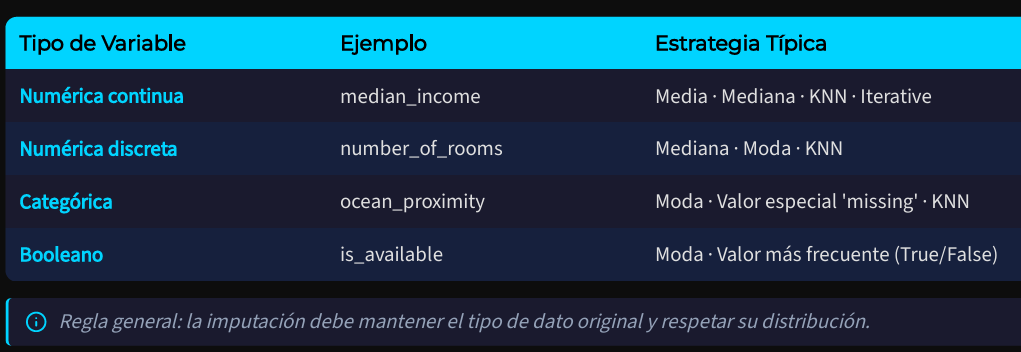

### Por distribución


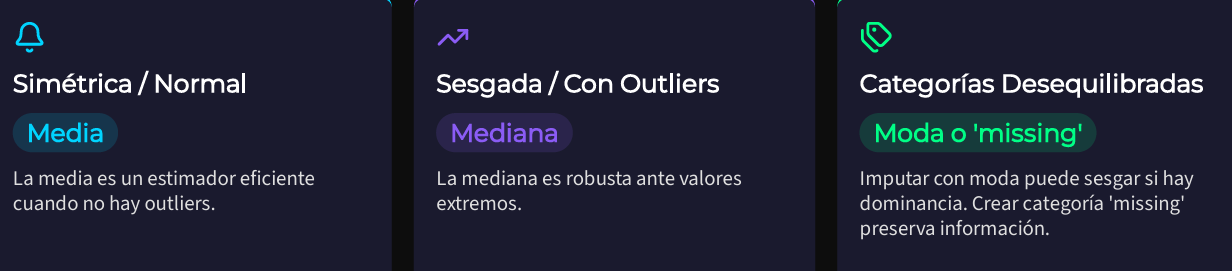

### Por porcentaje de valores faltantes y correlación con otras columnas

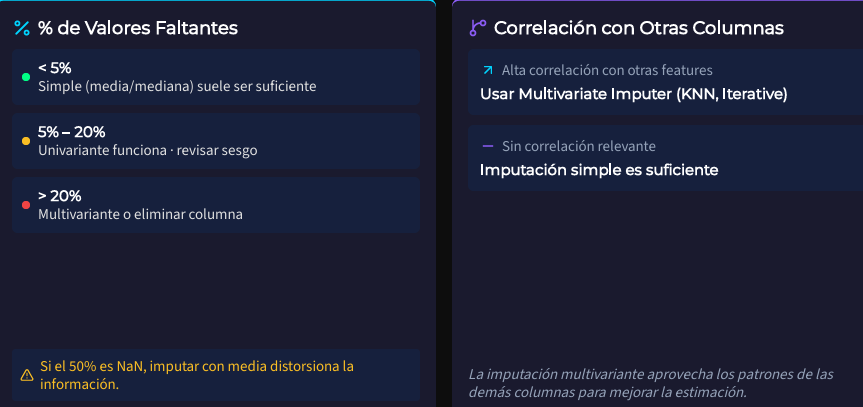

En este caso le falta datos a total **total_bedrooms** así que se analizará

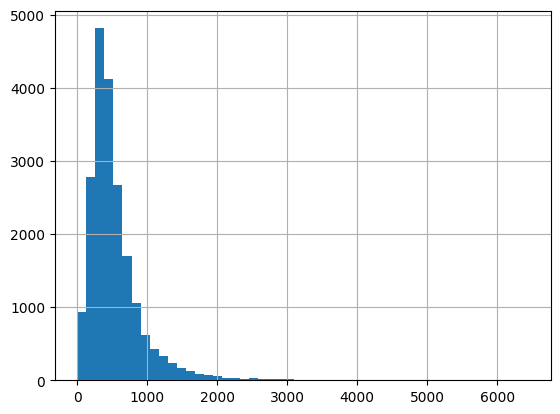

In [29]:
df_california_housing['total_bedrooms'].hist(bins=50)
plt.show()

Para eso vamos a utilizar imputación simple ya que solo trabajamos con esa columna y además hay valores atipicos. Por eso vamos a trabajar con la mediana.

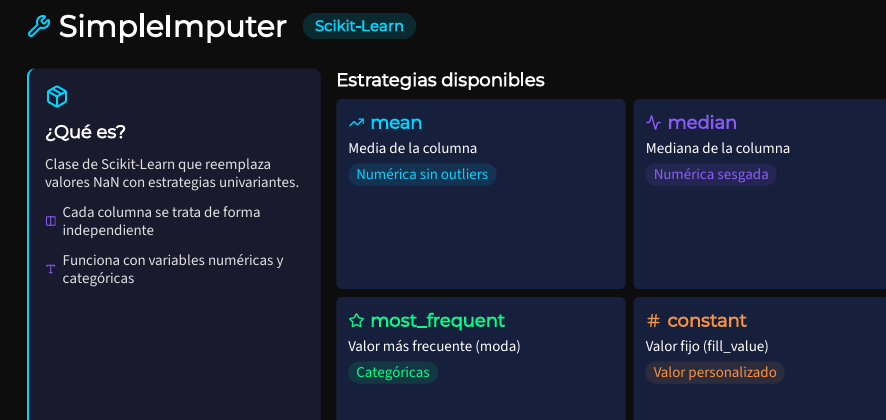

Esto de inputación lo realiza Scikit learn ya nos facilita esa parte. Por eso nos debemos concentrar en tomar las mejores decisiones para el dataset que estamos trabajando.

In [30]:
from sklearn.impute import SimpleImputer

imputer  = SimpleImputer(strategy="median")

In [31]:
# Seleccionar las categorias numericas
housing_num = X.select_dtypes(include=[np.number])

In [33]:
# Calculo de estadisticas de inputación de mediana columna por columna
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [ ]:
# Se observa la mediana de cada columna
imputer.statistics_

array([-118.49  ,   34.26  ,   29.    , 2127.    ,  435.    , 1166.    ,
        409.    ,    3.5348])

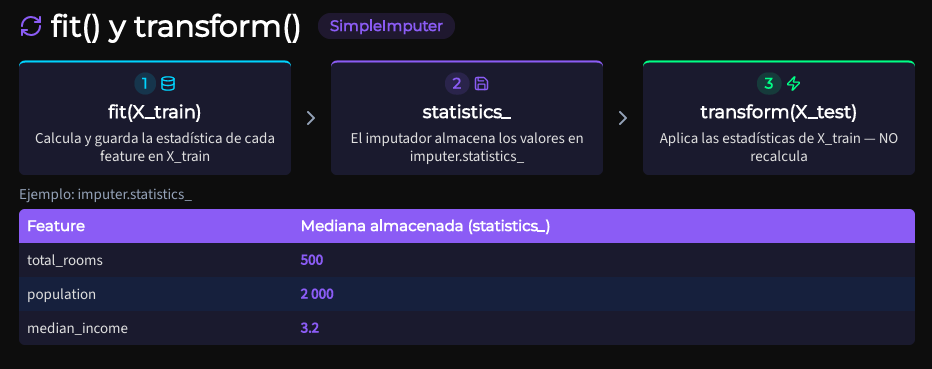

En la parte de imputar más adelante en el dataset de pruebas, se va a utilizar los valores estadisticos que se definio en el primer paso quedan almacenados.